In [1]:
import matplotlib as mpl
import matplotlib.pyplot as plt 
import numpy as np
import pandas as pd 
import random 
from torchvision.models import resnet50, ResNet50_Weights
from ignite.contrib.metrics.regression import MeanAbsoluteRelativeError
import optuna

from torch.utils.data import Dataset, DataLoader, random_split
import torch
import torchvision
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split
from torch import nn
import torch.nn.functional as F

from sklearn.cluster import KMeans
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
from os import listdir
from os.path import isfile, join
import pandas as pd
import os
import numpy as np
import umap
from sklearn.datasets import fetch_openml
import seaborn as sns
from sklearn import preprocessing
from sklearn import cluster
from sklearn import manifold
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor
import itertools

# First Attempt. Using padded(flawed) data:

In [2]:
#Getting the images:
unique_path = r"../data\grand_scraper_folder\unique_scrandle_pictures_FULL.csv"
unique_dataframe = pd.read_csv(unique_path)
unique_entries = [unique_dataframe["occurrences"][i].split("|")[0].split(" ")[0] + ".webp" for i in range(len(unique_dataframe["occurrences"]))]

#Next, we´ll get the low-res photos imported(doesnt take long. for my computer: 7.5s)

#Creating a list for the photos with the corresponding dates and image names as well(crude way of being able to see which are outliers.
#Needs to be done better, really. If someone has the time, feel free to find a better way of doing things)
image_Data_low_res = []




#Folder with folders of images:
base_folder = r"../data\scrandle_padded_low_res_data"

current_folder = None


#Looping over all dates in the listed directory/folder:
for entry in sorted(unique_entries):
    date, image_placement = entry.split(":")
    
    #Finding a new date folder to check
    date_path = os.path.join(base_folder, date)
    #Checking if the date path exists
    if not os.path.isdir(date_path):
        continue

    print(f"Processing {entry}")
    
    #Reading entry image:
    image_path = os.path.join(date_path, image_placement)
    image_Data_low_res.append({
                    "date": date,
                    "image_name": image_placement,
                    "RGB": plt.imread(image_path, format="webp"),
                })

Processing 2025-04-20:0_left.webp
Processing 2025-04-20:0_right.webp
Processing 2025-04-20:1_left.webp
Processing 2025-04-20:1_right.webp
Processing 2025-04-20:2_left.webp
Processing 2025-04-20:2_right.webp
Processing 2025-04-20:3_left.webp
Processing 2025-04-20:3_right.webp
Processing 2025-04-20:4_left.webp
Processing 2025-04-20:4_right.webp
Processing 2025-04-20:5_left.webp
Processing 2025-04-20:5_right.webp
Processing 2025-04-20:6_left.webp
Processing 2025-04-20:6_right.webp
Processing 2025-04-20:7_left.webp
Processing 2025-04-20:7_right.webp
Processing 2025-04-20:8_left.webp
Processing 2025-04-20:8_right.webp
Processing 2025-04-20:9_left.webp
Processing 2025-04-20:9_right.webp
Processing 2025-04-21:0_left.webp
Processing 2025-04-21:0_right.webp
Processing 2025-04-21:1_left.webp
Processing 2025-04-21:1_right.webp
Processing 2025-04-21:2_left.webp
Processing 2025-04-21:2_right.webp
Processing 2025-04-21:3_left.webp
Processing 2025-04-21:3_right.webp
Processing 2025-04-21:4_left.webp


In [3]:
#Settings:{'batch_size': 36, 'latent_dim': 91}
training_samples = 2500
batch_size = 36#110#22
latent_d = 91#110#88

In [4]:
#Getting only the images:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using Device: {device}")
image_only_low_res = []
for i in range(len(image_Data_low_res)):
    image_only_low_res.append(image_Data_low_res[i]["RGB"])

image_train = torch.from_numpy(np.array(image_only_low_res[:training_samples])/255).permute(0,3,1,2).float().to(device)
image_test = torch.from_numpy(np.array(image_only_low_res[training_samples:])/255).permute(0,3,1,2).float().to(device)

Using Device: cuda


In [5]:
#Next, for the dataloader:
class ImageDataset(Dataset):
    def __init__(self, images):
        
        self.images = images

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        image = self.images[idx]

        return image

dataset_train = ImageDataset(image_train)
dataset_test = ImageDataset(image_test)
loader_train = DataLoader(dataset_train, batch_size=batch_size, shuffle=True)
loader_test = DataLoader(dataset_test, batch_size=batch_size, shuffle=True)

### Model(Adapted from Troels autoencoder example solution)

In [6]:
class Encoder(nn.Module):
    
    def __init__(self, encoded_space_dim):
        super().__init__()
        
        ### Convolutional section:
        # So we decide to take our 1 input image and first apply 8 kernels/filters of size 3x3
        # with a stride (i.e. step size) of 2 and padding the edge with one layer.
        # This output goes through a ReLU and then through 16 new kernels/filters
        # of the same size, stride and padding, which is then BatchNorm'ed, ReLU'ed, and finally
        # convoluted a third time, again doubling the number of kernels/filters (quite standard!).
        self.encoder_cnn = nn.Sequential(
            nn.Conv2d(3, 8, 3, stride=2, padding=0),
            nn.ReLU(True),
            nn.Conv2d(8, 16, 3, stride=2, padding=0),
            nn.BatchNorm2d(16),
            nn.ReLU(True),
            nn.Conv2d(16, 32, 3, stride=2, padding=0),
            nn.ReLU(True)
        )
        
        ### Flatten layer
        # The images/matrices are then flatten'ed (put into one long array), put through a linear layer,
        # then a ReLU, and then finally another linear layer, which boils it down to the latent space
        # dimension.
        self.flatten = nn.Flatten(start_dim=1)
        ### Linear section
        self.encoder_lin = nn.Sequential(
            nn.Linear(11*9*32, 128),
            nn.ReLU(True),
            nn.Linear(128, encoded_space_dim)
        )
        
    def forward(self, x):
        x = self.encoder_cnn(x)
        x = self.flatten(x)
        x = self.encoder_lin(x)
        return x
    
class Decoder(nn.Module):
    
    def __init__(self, encoded_space_dim):
        super().__init__()
        self.decoder_lin = nn.Sequential(
            nn.Linear(encoded_space_dim, 128),
            nn.ReLU(True),
            nn.Linear(128, 11*9*32),
            nn.ReLU(True)
        )

        ### The decoder does the exact opposite, reconstructing the images from the latent space values.
        self.unflatten = nn.Unflatten(dim=1, 
        unflattened_size=(32, 11, 9))

        self.decoder_conv = nn.Sequential(
            nn.ConvTranspose2d(32, 16, 3, stride=2, output_padding=(1,1)),
            nn.BatchNorm2d(16),
            nn.ReLU(True),
            nn.ConvTranspose2d(16, 8, 3, stride=2, padding=0, output_padding=(0,1)),
            nn.BatchNorm2d(8),
            nn.ReLU(True),
            nn.ConvTranspose2d(8, 3, 3, stride=2, padding=0, output_padding=(1,0))
        )
        
    def forward(self, x):
        x = self.decoder_lin(x)
        x = self.unflatten(x)
        x = self.decoder_conv(x)
        x = torch.sigmoid(x)
        return x

In [7]:
# Define loss function and training parameters:
# Define the loss function
loss_fn = nn.L1Loss()

# Define an optimizer (both for the encoder and the decoder!)
lr = 0.001

# Set the random seed for reproducible results
torch.manual_seed(42)

# Initialize the two networks
#NOTE: d was initially 4. d=30 works really well!
#NOTE further: There seems to be a sweet spot between 30 and 50.
#d = 30
encoder = Encoder(encoded_space_dim=latent_d).to(device)
decoder = Decoder(encoded_space_dim=latent_d).to(device)
params_to_optimize = [
    {'params': encoder.parameters()},
    {'params': decoder.parameters()}
]

optimizer = torch.optim.Adam(params_to_optimize, lr=lr, weight_decay=1e-05)
optimizer

Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    weight_decay: 1e-05

Parameter Group 1
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    weight_decay: 1e-05
)

In [8]:
# Define training and validation functions:

### Training function
def train_epoch(encoder, decoder, dataloader, loss_fn, optimizer):
    # Set train mode for both the encoder and the decoder
    encoder.train()
    decoder.train()
    train_loss = []
    # Iterate the dataloader (we do not need the label values, this is unsupervised learning)
    for image_batch in dataloader: # with "_" we just ignore the labels (the second element of the dataloader tuple)
        # Encode data
        encoded_data = encoder(image_batch)
        # Decode data
        decoded_data = decoder(encoded_data)
        #test = decoded_data.detach().cpu()
        #break
        #Prining the decoded image:
        # Evaluate loss
        loss = loss_fn(decoded_data, image_batch)
        # Backward pass
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        # Print batch loss
#         print('\t partial train loss (single batch): %f' % (loss.data))
        train_loss.append(loss.detach().cpu().numpy())

    return np.mean(train_loss)
    #return test


### Testing function
def test_epoch(encoder, decoder, dataloader, loss_fn):
    # Set evaluation mode for encoder and decoder
    encoder.eval()
    decoder.eval()
    with torch.no_grad(): # No need to track the gradients
        # Define the lists to store the outputs for each batch
        conc_out = []
        conc_label = []
        for image_batch in dataloader:
            # Encode data
            encoded_data = encoder(image_batch)
            # Decode data
            decoded_data = decoder(encoded_data)
            # Append the network output and the original image to the lists
            conc_out.append(decoded_data.cpu())
            conc_label.append(image_batch.cpu())
        # Create a single tensor with all the values in the lists
        conc_out = torch.cat(conc_out)
        conc_label = torch.cat(conc_label) 
        # Evaluate global loss
        val_loss = loss_fn(conc_out, conc_label)
    return val_loss.data

In [9]:
diz_loss = {'train_loss':[],'val_loss':[]}
lrs = []

In [13]:
#code to change learning rate:

lr = 0.0001
params_to_optimize = [
    {'params': encoder.parameters()},
    {'params': decoder.parameters()}
]
optimizer = torch.optim.Adam(params_to_optimize, lr=lr, weight_decay=1e-05)
optimizer

Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.0001
    maximize: False
    weight_decay: 1e-05

Parameter Group 1
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.0001
    maximize: False
    weight_decay: 1e-05
)

In [14]:
# Train the model
torch.cuda.manual_seed(42)
#torch.use_deterministic_algorithms(True)

num_epochs = 50
for epoch in range(num_epochs):
    train_loss = train_epoch(encoder,decoder, loader_train, loss_fn, optimizer)
    val_loss = test_epoch(encoder,decoder,loader_test,loss_fn)
    print('\n EPOCH {}/{} \t train loss {} \t val loss {}'.format(epoch + 1, num_epochs,train_loss,val_loss))
    diz_loss['train_loss'].append(train_loss)
    diz_loss['val_loss'].append(val_loss)
    lrs.append(lr)


 EPOCH 1/50 	 train loss 0.08175742626190186 	 val loss 0.08361373096704483

 EPOCH 2/50 	 train loss 0.08132966607809067 	 val loss 0.0834016427397728

 EPOCH 3/50 	 train loss 0.08118481934070587 	 val loss 0.08353032916784286

 EPOCH 4/50 	 train loss 0.08106893301010132 	 val loss 0.08344895392656326

 EPOCH 5/50 	 train loss 0.08099037408828735 	 val loss 0.08336631208658218


KeyboardInterrupt: 

In [67]:
from mpl_toolkits.axes_grid1.inset_locator import zoomed_inset_axes
from mpl_toolkits.axes_grid1.inset_locator import mark_inset

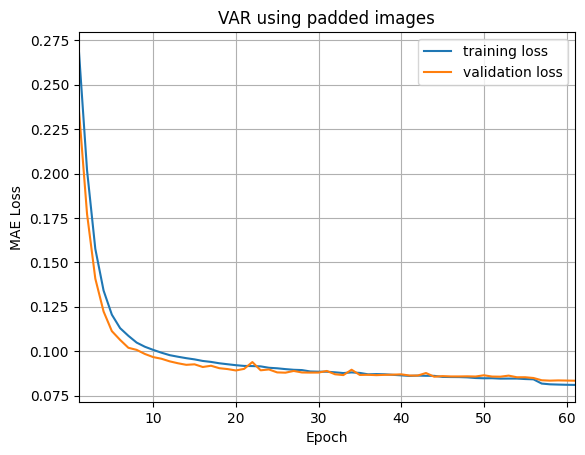

In [ ]:
#Plotting loss:
epochs = np.arange(1, len(diz_loss["train_loss"])+1, 1)
plt.plot(epochs, diz_loss["train_loss"], label = "training loss")
plt.plot(epochs, diz_loss["val_loss"], label = "validation loss")
plt.title("VAR using padded images")
plt.xlabel("Epoch")
plt.ylabel("MAE Loss")
plt.xlim(1, 61)
#plt.ylim(0.08, 0.1)
plt.legend()
plt.grid()

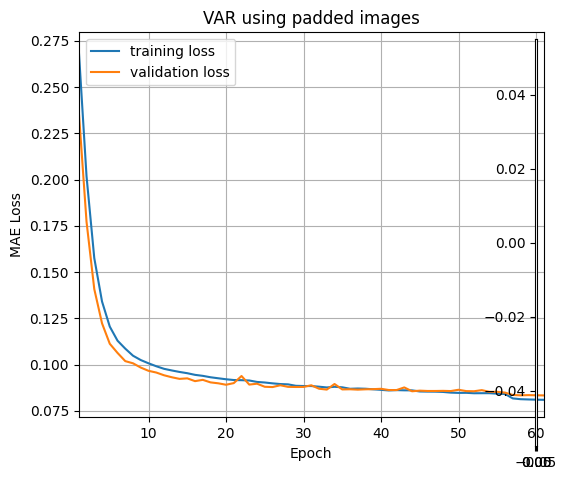

In [ ]:
fig, ax = plt.subplots(figsize=[6,5])
ax.plot(epochs, diz_loss["train_loss"], label = "training loss")
ax.plot(epochs, diz_loss["val_loss"], label = "validation loss")
ax.set_title("VAR using padded images")
ax.set_ylabel("MAE Loss")
ax.set_xlabel("Epoch")
ax.set_xlim(1,61)
ax.legend(loc=2)

ax_zoom = zoomed_inset_axes(ax, 2, loc=1)
ax_zoom.set_ylim(0.075, 0.125)
ax_zoom.set_xlim(35,45)
#mark_inset(ax, ax_zoom, loc1=2, loc2=4)
ax.grid()

In [25]:
encoder.eval()
decoder.eval()

Decoder(
  (decoder_lin): Sequential(
    (0): Linear(in_features=91, out_features=128, bias=True)
    (1): ReLU(inplace=True)
    (2): Linear(in_features=128, out_features=3168, bias=True)
    (3): ReLU(inplace=True)
  )
  (unflatten): Unflatten(dim=1, unflattened_size=(32, 11, 9))
  (decoder_conv): Sequential(
    (0): ConvTranspose2d(32, 16, kernel_size=(3, 3), stride=(2, 2), output_padding=(1, 1))
    (1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): ConvTranspose2d(16, 8, kernel_size=(3, 3), stride=(2, 2), output_padding=(0, 1))
    (4): BatchNorm2d(8, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (5): ReLU(inplace=True)
    (6): ConvTranspose2d(8, 3, kernel_size=(3, 3), stride=(2, 2), output_padding=(1, 0))
  )
)

In [26]:
#Here to save models:
#torch.save(encoder.state_dict(), "padded_data_encoder")
#torch.save(decoder.state_dict(), "padded_data_decoder")

In [27]:
def check_encoder(image_id, train_test):
    reconstruct = decoder(encoder(train_test[image_id].unsqueeze(1).cpu().permute(1,0,2,3).to(device))).detach().cpu().numpy()[0].transpose(1,2,0)
    original = train_test[image_id].cpu().numpy().transpose(1,2,0)
    return reconstruct, original

Showing image comparison for image nr. 797


<Figure size 1200x12000 with 0 Axes>

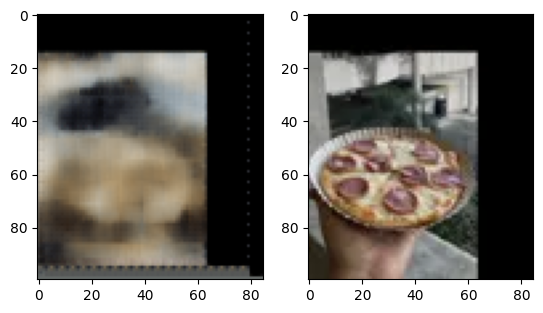

In [35]:
plt.figure(figsize=(12, 120))
random_num = np.random.randint(0, training_samples)#2397
image_id = random_num#390
#NOTE: tried running with nearly all data as training data after sending image on discord!
#subplot(r,c) provide the no. of rows and columns
print("Showing image comparison for image nr.", random_num)
f, axarr = plt.subplots(1,2) 

# use the created array to output your multiple images. In this case I have stacked 4 images vertically
axarr[0].imshow(check_encoder(image_id, image_train)[0])
axarr[1].imshow(check_encoder(image_id, image_train)[1])



Showing image comparison for image nr. 486


<Figure size 1200x12000 with 0 Axes>

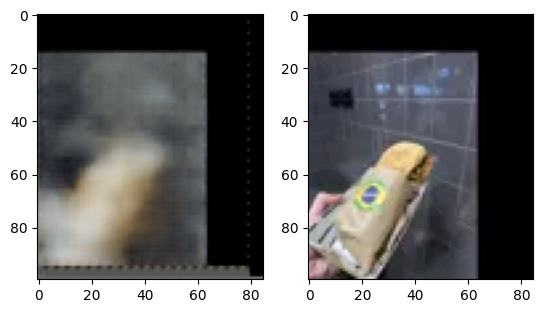

In [61]:
plt.figure(figsize=(12, 120))
random_num2 = np.random.randint(0, len(image_only_low_res[training_samples:]))
image_id = random_num2
print("Showing image comparison for image nr.", random_num2)
#NOTE: tried running with nearly all data as training data after sending image on discord!
#subplot(r,c) provide the no. of rows and columns
f, axarr = plt.subplots(1,2) 

# use the created array to output your multiple images. In this case I have stacked 4 images vertically
axarr[0].imshow(check_encoder(image_id, image_test)[0])
axarr[1].imshow(check_encoder(image_id, image_test)[1])

In [ ]:
print(breakks)

### Optimizing some parameters using optuna:

In [ ]:
import optuna
torch.backends.cudnn.deterministic = True

def objective(trial):
    batch_size = trial.suggest_int('batch_size', 20, 120)
    #weight_decay = trial.suggest_float("weight_decay", 0.00001, 0.0001)
    latent_dim = trial.suggest_int("latent_dim", 10, 150)
    device = "cuda" if torch.cuda.is_available() else "cpu"

    image_train = torch.from_numpy(np.array(image_only_low_res[:training_samples])/255).permute(0,3,1,2).float().to(device)
    image_test = torch.from_numpy(np.array(image_only_low_res[training_samples:])/255).permute(0,3,1,2).float().to(device)

    class ImageDataset(Dataset):
        def __init__(self, images):
        
            self.images = images

        def __len__(self):
            return len(self.images)

        def __getitem__(self, idx):
            image = self.images[idx]

            return image

    dataset_train = ImageDataset(image_train)
    dataset_test = ImageDataset(image_test)
    loader_train = DataLoader(dataset_train, batch_size=batch_size, shuffle=True)
    loader_test = DataLoader(dataset_test, batch_size=batch_size, shuffle=True)
    class Encoder(nn.Module):
    
        def __init__(self, encoded_space_dim):
            super().__init__()
        
        ### Convolutional section:
        # So we decide to take our 1 input image and first apply 8 kernels/filters of size 3x3
        # with a stride (i.e. step size) of 2 and padding the edge with one layer.
        # This output goes through a ReLU and then through 16 new kernels/filters
        # of the same size, stride and padding, which is then BatchNorm'ed, ReLU'ed, and finally
        # convoluted a third time, again doubling the number of kernels/filters (quite standard!).
            self.encoder_cnn = nn.Sequential(
                nn.Conv2d(3, 8, 3, stride=2, padding=0),
                nn.ReLU(True),
                nn.Conv2d(8, 16, 3, stride=2, padding=0),
                nn.BatchNorm2d(16),
                nn.ReLU(True),
                nn.Conv2d(16, 32, 3, stride=2, padding=0),
                nn.ReLU(True)
            )
        
        ### Flatten layer
        # The images/matrices are then flatten'ed (put into one long array), put through a linear layer,
        # then a ReLU, and then finally another linear layer, which boils it down to the latent space
        # dimension.
            self.flatten = nn.Flatten(start_dim=1)
        ### Linear section
            self.encoder_lin = nn.Sequential(
                nn.Linear(11*9*32, 128),
                nn.ReLU(True),
                nn.Linear(128, encoded_space_dim)
            )
        
        def forward(self, x):
            x = self.encoder_cnn(x)
            x = self.flatten(x)
            x = self.encoder_lin(x)
            return x
    
    class Decoder(nn.Module):
    
        def __init__(self, encoded_space_dim):
            super().__init__()
            self.decoder_lin = nn.Sequential(
                nn.Linear(encoded_space_dim, 128),
                nn.ReLU(True),
                nn.Linear(128, 11*9*32),
                nn.ReLU(True)
            )

        ### The decoder does the exact opposite, reconstructing the images from the latent space values.
            self.unflatten = nn.Unflatten(dim=1, 
            unflattened_size=(32, 11, 9))

            self.decoder_conv = nn.Sequential(
                nn.ConvTranspose2d(32, 16, 3, stride=2, output_padding=(1,1)),
                nn.BatchNorm2d(16),
                nn.ReLU(True),
                nn.ConvTranspose2d(16, 8, 3, stride=2, padding=0, output_padding=(0,1)),
                nn.BatchNorm2d(8),
                nn.ReLU(True),
                nn.ConvTranspose2d(8, 3, 3, stride=2, padding=0, output_padding=(1,0))
            )
        
        def forward(self, x):
            x = self.decoder_lin(x)
            x = self.unflatten(x)
            x = self.decoder_conv(x)
            x = torch.sigmoid(x)
            return x
        loss_fn = nn.L1Loss()

# Define an optimizer (both for the encoder and the decoder!)
    lr = 0.001

# Set the random seed for reproducible results
    torch.manual_seed(42)

# Initialize the two networks
#NOTE: d was initially 4. d=30 works really well!
#NOTE further: There seems to be a sweet spot between 30 and 50.
#d = 30

    optimizer = torch.optim.Adam(params_to_optimize, lr=lr, weight_decay=1e-05)


    torch.manual_seed(42)
    random.seed(42)
    np.random.seed(42)
    lr = 0.001
    encoder_opt = Encoder(encoded_space_dim=latent_dim).to(device)
    decoder_opt = Decoder(encoded_space_dim=latent_dim).to(device)
    params_to_optimize_opt = [
    {'params': encoder_opt.parameters()},
    {'params': decoder_opt.parameters()}
    ]
    num_epochs = 50
    torch.cuda.manual_seed(42)
    optimizer_opt = torch.optim.Adam(params_to_optimize_opt, lr=lr, weight_decay=0.00001)
    for epoch in range(num_epochs):
        #if epoch == 0:
            #torch.cuda.manual_seed_all(42)
            #torch.use_deterministic_algorithms(True)
        train_loss = train_epoch(encoder_opt, decoder_opt, loader_train, loss_fn, optimizer_opt)
        val_loss = test_epoch(encoder_opt, decoder_opt, loader_test, loss_fn)

    return val_loss

study = optuna.create_study(study_name="autoencoder study", direction='minimize', sampler=torch.cuda.manual_seed(42))
study.optimize(objective, n_trials=150, show_progress_bar=True, n_jobs=1)


study.best_params

[I 2026-06-04 09:36:45,064] A new study created in memory with name: autoencoder study


  0%|          | 0/150 [00:00<?, ?it/s]

[W 2026-06-04 09:37:12,927] Trial 0 failed with parameters: {'batch_size': 32, 'latent_dim': 69} because of the following error: KeyboardInterrupt().
Traceback (most recent call last):
  File "c:\Users\Chris\anaconda3\envs\PYTHON313\Lib\site-packages\optuna\study\_optimize.py", line 206, in _run_trial
    value_or_values = func(trial)
  File "C:\Users\Chris\AppData\Local\Temp\ipykernel_8684\226599622.py", line 133, in objective
    train_loss = train_epoch(encoder_opt, decoder_opt, loader_train, loss_fn, optimizer_opt)
  File "C:\Users\Chris\AppData\Local\Temp\ipykernel_8684\84457626.py", line 21, in train_epoch
    optimizer.zero_grad()
    ~~~~~~~~~~~~~~~~~~~^^
  File "c:\Users\Chris\anaconda3\envs\PYTHON313\Lib\site-packages\torch\_compile.py", line 54, in inner
    return disable_fn(*args, **kwargs)
  File "c:\Users\Chris\anaconda3\envs\PYTHON313\Lib\site-packages\torch\_dynamo\eval_frame.py", line 1298, in _fn
    return fn(*args, **kwargs)
  File "c:\Users\Chris\anaconda3\envs\PY

KeyboardInterrupt: 

### Next, lets get all the loss values, and plot them:


In [ ]:
#All images in torch tensors:
image_torch = torch.from_numpy(np.array(image_only_low_res[:])/255).permute(0,3,1,2).float().to(device)
image_loss = []
def check_encoder_torch(image_id, train_test):
    reconstruct = decoder(encoder(train_test[image_id].unsqueeze(1).cpu().permute(1,0,2,3).to(device))).cpu()[0]#.permute(1,2,0)
    original = train_test[image_id].cpu()#.numpy().transpose(1,2,0)
    return reconstruct, original
for i in range(len(image_torch)):
    rec, orig = check_encoder_torch(i, image_torch)
    #rec_cat = nn.cat(rec)
    #orig_cat = orig.flatten()
    val_loss = loss_fn(rec, orig)
    image_loss.append(val_loss.detach().numpy())





In [52]:
image_ids

array([   1,    2,    3, ..., 3190, 3191, 3192], shape=(3192,))

(1.0, 3192.0)

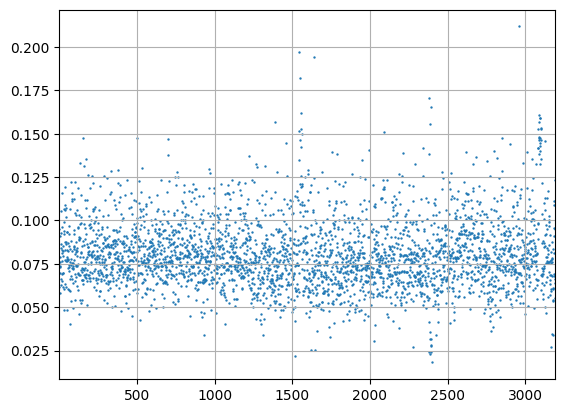

In [57]:
image_ids = np.arange(1, len(image_loss)+1, 1)
plt.scatter(image_ids, image_loss, s=0.5)
plt.grid()
plt.xlim(1, 3192)

In [105]:
#Constructing a list of sorted images by loss:
#np.argsort(image_ids, image_loss)
stack = np.vstack([image_ids, image_loss])
sorted_images_ids = np.argsort(stack)
sorted_image_loss = np.sort(image_loss)

(1.0, 3192.0)

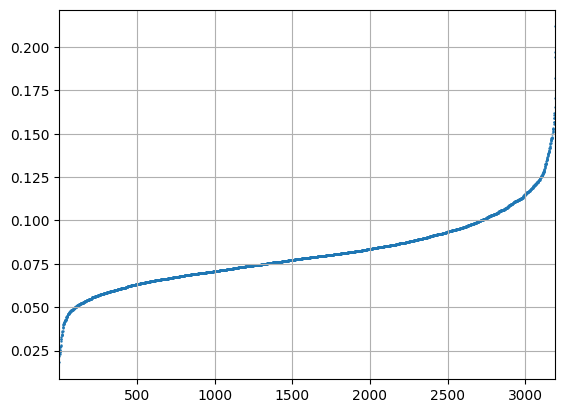

In [110]:
image_ids = np.arange(1, len(image_loss)+1, 1)
plt.scatter(image_ids, sorted_image_loss, s=0.5)
plt.grid()
plt.xlim(1, 3192)

In [111]:
sorted_images_ids[1]

array([2397, 1516, 2387, ..., 1639, 1545, 2955], shape=(3193,))

(array([2.300e+01, 2.290e+02, 1.175e+03, 1.158e+03, 4.120e+02, 1.370e+02,
        4.600e+01, 9.000e+00, 1.000e+00, 3.000e+00]),
 array([0.01813088, 0.03750224, 0.0568736 , 0.07624497, 0.09561633,
        0.11498769, 0.13435906, 0.15373042, 0.17310178, 0.19247314,
        0.2118445 ]),
 <BarContainer object of 10 artists>)

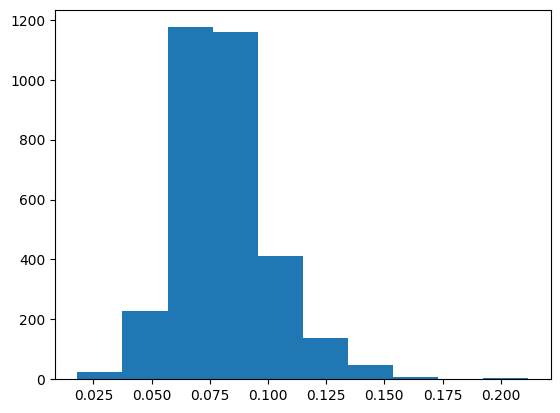

In [107]:
plt.hist(image_loss)

## Now, lets use the scrandle processed images:

In [7]:
#Getting the images:
unique_path = r"../data\grand_scraper_folder\unique_scrandle_pictures_FULL.csv"
unique_dataframe = pd.read_csv(unique_path)
unique_entries = [unique_dataframe["occurrences"][i].split("|")[0].split(" ")[0] + ".webp" for i in range(len(unique_dataframe["occurrences"]))]

#Next, we´ll get the low-res photos imported(doesnt take long. for my computer: 7.5s)

#Creating a list for the photos with the corresponding dates and image names as well(crude way of being able to see which are outliers.
#Needs to be done better, really. If someone has the time, feel free to find a better way of doing things)
image_scran_low_res = []




#Folder with folders of images:
base_folder = r"../data\scran_sized_low_res_data"

current_folder = None


#Looping over all dates in the listed directory/folder:
for entry in sorted(unique_entries):
    date, image_placement = entry.split(":")
    
    #Finding a new date folder to check
    date_path = os.path.join(base_folder, date)
    #Checking if the date path exists
    if not os.path.isdir(date_path):
        continue

    print(f"Processing {entry}")
    
    #Reading entry image:
    image_path = os.path.join(date_path, image_placement)
    image_scran_low_res.append({
                    "date": date,
                    "image_name": image_placement,
                    "RGB": plt.imread(image_path, format="webp"),
                })

Processing 2025-04-20:0_left.webp
Processing 2025-04-20:0_right.webp
Processing 2025-04-20:1_left.webp
Processing 2025-04-20:1_right.webp
Processing 2025-04-20:2_left.webp
Processing 2025-04-20:2_right.webp
Processing 2025-04-20:3_left.webp
Processing 2025-04-20:3_right.webp
Processing 2025-04-20:4_left.webp
Processing 2025-04-20:4_right.webp
Processing 2025-04-20:5_left.webp
Processing 2025-04-20:5_right.webp
Processing 2025-04-20:6_left.webp
Processing 2025-04-20:6_right.webp
Processing 2025-04-20:7_left.webp
Processing 2025-04-20:7_right.webp
Processing 2025-04-20:8_left.webp
Processing 2025-04-20:8_right.webp
Processing 2025-04-20:9_left.webp
Processing 2025-04-20:9_right.webp
Processing 2025-04-21:0_left.webp
Processing 2025-04-21:0_right.webp
Processing 2025-04-21:1_left.webp
Processing 2025-04-21:1_right.webp
Processing 2025-04-21:2_left.webp
Processing 2025-04-21:2_right.webp
Processing 2025-04-21:3_left.webp
Processing 2025-04-21:3_right.webp
Processing 2025-04-21:4_left.webp


In [301]:
#Settings:{'batch_size': 96, 'latent_dim': 145}
batch_size = 96#110#22
latent_d = 145#110#88

In [302]:
#New encoder decoder stuff
class EncoderQ(nn.Module):
    
    def __init__(self, encoded_space_dim):
        super().__init__()
        
        ### Convolutional section:
        # So we decide to take our 1 input image and first apply 8 kernels/filters of size 3x3
        # with a stride (i.e. step size) of 2 and padding the edge with one layer.
        # This output goes through a ReLU and then through 16 new kernels/filters
        # of the same size, stride and padding, which is then BatchNorm'ed, ReLU'ed, and finally
        # convoluted a third time, again doubling the number of kernels/filters (quite standard!).
        self.encoder_cnn = nn.Sequential(
            nn.Conv2d(3, 8, 3, stride=2, padding=0),
            nn.ReLU(True),
            nn.Conv2d(8, 16, 3, stride=2, padding=0),
            nn.BatchNorm2d(16),
            nn.ReLU(True),
            nn.Conv2d(16, 32, 3, stride=2, padding=0),
            nn.ReLU(True)
        )
        
        ### Flatten layer
        # The images/matrices are then flatten'ed (put into one long array), put through a linear layer,
        # then a ReLU, and then finally another linear layer, which boils it down to the latent space
        # dimension.
        self.flatten = nn.Flatten(start_dim=1)
        ### Linear section
        self.encoder_lin = nn.Sequential(
            nn.Linear(11*9*32, 128),
            nn.ReLU(True),
            nn.Linear(128, encoded_space_dim)
        )
        
    def forward(self, x):
        x = self.encoder_cnn(x)
        x = self.flatten(x)
        x = self.encoder_lin(x)
        return x
    
class DecoderQ(nn.Module):
    
    def __init__(self, encoded_space_dim):
        super().__init__()
        self.decoder_lin = nn.Sequential(
            nn.Linear(encoded_space_dim, 128),
            nn.ReLU(True),
            nn.Linear(128, 11*9*32),
            nn.ReLU(True)
        )

        ### The decoder does the exact opposite, reconstructing the images from the latent space values.
        self.unflatten = nn.Unflatten(dim=1, 
        unflattened_size=(32, 9, 11))

        self.decoder_conv = nn.Sequential(
            nn.ConvTranspose2d(32, 16, 3, stride=2, output_padding=(1,1)),
            nn.BatchNorm2d(16),
            nn.ReLU(True),
            nn.ConvTranspose2d(16, 8, 3, stride=2, padding=0, output_padding=(1,1)),
            nn.BatchNorm2d(8),
            nn.ReLU(True),
            nn.ConvTranspose2d(8, 3, 3, stride=2, padding=0, output_padding=(0,1))
        )
        
    def forward(self, x):
        x = self.decoder_lin(x)
        x = self.unflatten(x)
        x = self.decoder_conv(x)
        x = torch.sigmoid(x)
        return x

In [303]:
#Getting only the images:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using Device: {device}")
image_only_scran = []
for i in range(len(image_scran_low_res)):
    image_only_scran.append(image_scran_low_res[i]["RGB"])

image_scran_torch_pre = torch.from_numpy(np.array(image_only_scran[:])/255).permute(0,3,1,2).float().to(device)

image_scran_torch = ImageDataset(image_scran_torch_pre)
train_size = int(0.8 * len(image_scran_torch))
test_size = len(image_scran_torch) - train_size
train_dataset, test_dataset = random_split(image_scran_torch, [train_size, test_size], generator=torch.Generator().manual_seed(42))

loader_trainQ = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
loader_testQ = DataLoader(test_dataset, batch_size=batch_size, shuffle=True)

Using Device: cuda


In [304]:
# Define loss function and training parameters:
# Define the loss function
loss_fn = nn.L1Loss()

# Set the random seed for reproducible results
torch.manual_seed(42)

# Initialize the two networks
#NOTE: d was initially 4. d=30 works really well!
#NOTE further: There seems to be a sweet spot between 30 and 50.
#d = 30
lr = 0.001
encoderQ = EncoderQ(encoded_space_dim=latent_d).to(device)
decoderQ = DecoderQ(encoded_space_dim=latent_d).to(device)
params_to_optimizeQ = [
    {'params': encoderQ.parameters()},
    {'params': decoderQ.parameters()}
]

optimizerQ = torch.optim.Adam(params_to_optimizeQ, lr=lr, weight_decay=1e-05)
optimizerQ

Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    weight_decay: 1e-05

Parameter Group 1
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    weight_decay: 1e-05
)

In [305]:
diz_lossQ = {'train_loss':[],'val_loss':[]}
lrsQ = []

In [308]:
#lr changer
lr = 0.0001
params_to_optimizeQ = [
    {'params': encoderQ.parameters()},
    {'params': decoderQ.parameters()}
]
optimizerQ = torch.optim.Adam(params_to_optimizeQ, lr=lr, weight_decay=1e-05)
optimizerQ

Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.0001
    maximize: False
    weight_decay: 1e-05

Parameter Group 1
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.0001
    maximize: False
    weight_decay: 1e-05
)

In [309]:
# Train the model
torch.cuda.manual_seed(42)
#torch.use_deterministic_algorithms(True)

num_epochs = 50
for epoch in range(num_epochs):
    train_loss = train_epoch(encoderQ, decoderQ, loader_trainQ, loss_fn, optimizerQ)
    val_loss = test_epoch(encoderQ, decoderQ, loader_testQ, loss_fn)
    print('\n EPOCH {}/{} \t train loss {} \t val loss {}'.format(epoch + 1, num_epochs,train_loss,val_loss))
    diz_lossQ['train_loss'].append(train_loss)
    diz_lossQ['val_loss'].append(val_loss)
    lrsQ.append(lr)


 EPOCH 1/50 	 train loss 0.10826613008975983 	 val loss 0.11450187861919403

 EPOCH 2/50 	 train loss 0.10788175463676453 	 val loss 0.11432842910289764

 EPOCH 3/50 	 train loss 0.10773972421884537 	 val loss 0.11415410041809082

 EPOCH 4/50 	 train loss 0.10761192440986633 	 val loss 0.11417937278747559

 EPOCH 5/50 	 train loss 0.10753379017114639 	 val loss 0.11414606124162674

 EPOCH 6/50 	 train loss 0.10764456540346146 	 val loss 0.11415800452232361

 EPOCH 7/50 	 train loss 0.1075514480471611 	 val loss 0.1141386404633522

 EPOCH 8/50 	 train loss 0.10740292817354202 	 val loss 0.1141381710767746

 EPOCH 9/50 	 train loss 0.1073121428489685 	 val loss 0.11419413983821869

 EPOCH 10/50 	 train loss 0.10747171193361282 	 val loss 0.11407296359539032

 EPOCH 11/50 	 train loss 0.10733913630247116 	 val loss 0.114036925137043

 EPOCH 12/50 	 train loss 0.10724543780088425 	 val loss 0.11405553668737411

 EPOCH 13/50 	 train loss 0.1073044165968895 	 val loss 0.11411025375127792

 

In [310]:
encoderQ.eval()
decoderQ.eval()

DecoderQ(
  (decoder_lin): Sequential(
    (0): Linear(in_features=145, out_features=128, bias=True)
    (1): ReLU(inplace=True)
    (2): Linear(in_features=128, out_features=3168, bias=True)
    (3): ReLU(inplace=True)
  )
  (unflatten): Unflatten(dim=1, unflattened_size=(32, 9, 11))
  (decoder_conv): Sequential(
    (0): ConvTranspose2d(32, 16, kernel_size=(3, 3), stride=(2, 2), output_padding=(1, 1))
    (1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): ConvTranspose2d(16, 8, kernel_size=(3, 3), stride=(2, 2), output_padding=(1, 1))
    (4): BatchNorm2d(8, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (5): ReLU(inplace=True)
    (6): ConvTranspose2d(8, 3, kernel_size=(3, 3), stride=(2, 2), output_padding=(0, 1))
  )
)

In [311]:
def check_encoderQ(image_id, train_test):
    reconstruct = decoderQ(encoderQ(train_test[image_id].unsqueeze(1).cpu().permute(1,0,2,3).to(device))).detach().cpu().numpy()[0].transpose(1,2,0)
    original = train_test[image_id].cpu().numpy().transpose(1,2,0)
    return reconstruct, original

Showing image comparison for image nr. 459


<Figure size 1200x12000 with 0 Axes>

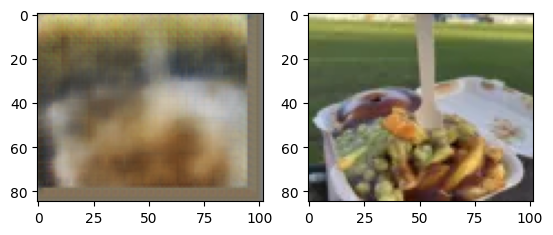

In [334]:
plt.figure(figsize=(12, 120))
random_num = np.random.randint(0, len(train_dataset))#2397
image_id = random_num#390
#NOTE: tried running with nearly all data as training data after sending image on discord!
#subplot(r,c) provide the no. of rows and columns
print("Showing image comparison for image nr.", random_num)
f, axarr = plt.subplots(1,2) 

# use the created array to output your multiple images. In this case I have stacked 4 images vertically
axarr[0].imshow(check_encoderQ(image_id, train_dataset)[0])
axarr[1].imshow(check_encoderQ(image_id, train_dataset)[1])

Showing image comparison for image nr. 13


<Figure size 1200x12000 with 0 Axes>

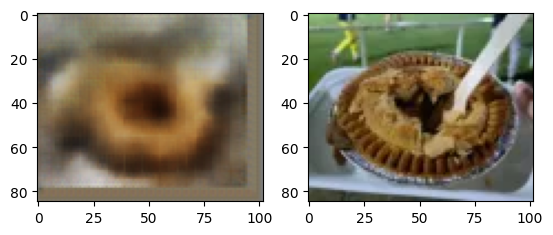

In [356]:
plt.figure(figsize=(12, 120))
random_num = np.random.randint(0, len(test_dataset))#2397
image_id = random_num#390
#NOTE: tried running with nearly all data as training data after sending image on discord!
#subplot(r,c) provide the no. of rows and columns
print("Showing image comparison for image nr.", random_num)
f, axarr = plt.subplots(1,2) 

# use the created array to output your multiple images. In this case I have stacked 4 images vertically
axarr[0].imshow(check_encoderQ(image_id, test_dataset)[0])
axarr[1].imshow(check_encoderQ(image_id, test_dataset)[1])

In [155]:
train_dataset[0]

tensor([[[0.5804, 0.5922, 0.6039,  ..., 0.6510, 0.6627, 0.6627],
         [0.6039, 0.6078, 0.6078,  ..., 0.6784, 0.6353, 0.6353],
         [0.6431, 0.6314, 0.6118,  ..., 0.6510, 0.6275, 0.6275],
         ...,
         [0.6549, 0.6824, 0.6706,  ..., 0.7608, 0.7490, 0.7451],
         [0.6471, 0.6863, 0.6863,  ..., 0.8353, 0.8000, 0.7725],
         [0.6275, 0.6745, 0.6863,  ..., 0.8902, 0.8863, 0.8549]],

        [[0.5608, 0.5608, 0.5608,  ..., 0.6078, 0.6235, 0.6235],
         [0.5843, 0.5765, 0.5647,  ..., 0.6353, 0.5961, 0.5961],
         [0.6196, 0.5961, 0.5686,  ..., 0.6078, 0.5843, 0.5843],
         ...,
         [0.5725, 0.6000, 0.5843,  ..., 0.6353, 0.6314, 0.6353],
         [0.5647, 0.6039, 0.6039,  ..., 0.7098, 0.6863, 0.6627],
         [0.5451, 0.5922, 0.6039,  ..., 0.7647, 0.7725, 0.7451]],

        [[0.4784, 0.4824, 0.4941,  ..., 0.5255, 0.5451, 0.5451],
         [0.5020, 0.4980, 0.4980,  ..., 0.5529, 0.5176, 0.5176],
         [0.5373, 0.5176, 0.5059,  ..., 0.5255, 0.5098, 0.

In [300]:
torch.backends.cudnn.deterministic = True


def objectiveQ(trial):
    batch_size = trial.suggest_int('batch_size', 20, 120)
    latent_dim = trial.suggest_int("latent_dim", 10, 150)
    device = "cuda" if torch.cuda.is_available() else "cpu"
    image_scran_torch_pre = torch.from_numpy(np.array(image_only_scran[:])/255).permute(0,3,1,2).float().to(device)
    class ImageDataset(Dataset):
        def __init__(self, images):
        
            self.images = images

        def __len__(self):
            return len(self.images)

        def __getitem__(self, idx):
            image = self.images[idx]

            return image

    image_scran_torch = ImageDataset(image_scran_torch_pre)
    train_size = int(0.8 * len(image_scran_torch))
    test_size = len(image_scran_torch) - train_size
    train_dataset_opt, test_dataset_opt = random_split(image_scran_torch, [train_size, test_size], generator=torch.Generator().manual_seed(42))

    loader_trainQ_opt = DataLoader(train_dataset_opt, batch_size=batch_size, shuffle=True)
    loader_testQ_opt = DataLoader(test_dataset_opt, batch_size=batch_size, shuffle=True)
    #New encoder decoder stuff
    class EncoderQ_opt(nn.Module):
        
        def __init__(self, encoded_space_dim):
            super().__init__()
            
            ### Convolutional section:
            # So we decide to take our 1 input image and first apply 8 kernels/filters of size 3x3
            # with a stride (i.e. step size) of 2 and padding the edge with one layer.
            # This output goes through a ReLU and then through 16 new kernels/filters
            # of the same size, stride and padding, which is then BatchNorm'ed, ReLU'ed, and finally
            # convoluted a third time, again doubling the number of kernels/filters (quite standard!).
            self.encoder_cnn = nn.Sequential(
                nn.Conv2d(3, 8, 3, stride=2, padding=0),
                nn.ReLU(True),
                nn.Conv2d(8, 16, 3, stride=2, padding=0),
                nn.BatchNorm2d(16),
                nn.ReLU(True),
                nn.Conv2d(16, 32, 3, stride=2, padding=0),
                nn.ReLU(True)
            )
            
            ### Flatten layer
            # The images/matrices are then flatten'ed (put into one long array), put through a linear layer,
            # then a ReLU, and then finally another linear layer, which boils it down to the latent space
            # dimension.
            self.flatten = nn.Flatten(start_dim=1)
            ### Linear section
            self.encoder_lin = nn.Sequential(
                nn.Linear(11*9*32, 128),
                nn.ReLU(True),
                nn.Linear(128, encoded_space_dim)
            )
            
        def forward(self, x):
            x = self.encoder_cnn(x)
            x = self.flatten(x)
            x = self.encoder_lin(x)
            return x
        
    class DecoderQ_opt(nn.Module):
        
        def __init__(self, encoded_space_dim):
            super().__init__()
            self.decoder_lin = nn.Sequential(
                nn.Linear(encoded_space_dim, 128),
                nn.ReLU(True),
                nn.Linear(128, 11*9*32),
                nn.ReLU(True)
            )
    
            ### The decoder does the exact opposite, reconstructing the images from the latent space values.
            self.unflatten = nn.Unflatten(dim=1, 
            unflattened_size=(32, 9, 11))
    
            self.decoder_conv = nn.Sequential(
                nn.ConvTranspose2d(32, 16, 3, stride=2, output_padding=(1,1)),
                nn.BatchNorm2d(16),
                nn.ReLU(True),
                nn.ConvTranspose2d(16, 8, 3, stride=2, padding=0, output_padding=(1,1)),
                nn.BatchNorm2d(8),
                nn.ReLU(True),
                nn.ConvTranspose2d(8, 3, 3, stride=2, padding=0, output_padding=(0,1))
            )
            
        def forward(self, x):
            x = self.decoder_lin(x)
            x = self.unflatten(x)
            x = self.decoder_conv(x)
            x = torch.sigmoid(x)
            return x
        # Define an optimizer (both for the encoder and the decoder!)
    torch.manual_seed(42)
    lr = 0.001
    encoderQ_opt = EncoderQ(encoded_space_dim=latent_dim).to(device)
    decoderQ_opt = DecoderQ(encoded_space_dim=latent_dim).to(device)
    params_to_optimizeQ_opt = [
        {'params': encoderQ_opt.parameters()},
        {'params': decoderQ_opt.parameters()}
    ]
    optimizerQ_opt = torch.optim.Adam(params_to_optimizeQ_opt, lr=lr, weight_decay=1e-05)
    loss_fn = nn.L1Loss()

    torch.manual_seed(42)
    random.seed(42)
    np.random.seed(42)
    num_epochs = 50
    for epoch in range(num_epochs):
        train_loss = train_epoch(encoderQ_opt, decoderQ_opt, loader_trainQ_opt, loss_fn, optimizerQ_opt)
        val_loss = test_epoch(encoderQ_opt, decoderQ_opt, loader_testQ_opt, loss_fn)
    
    return val_loss

studyQ = optuna.create_study(study_name="autoencoder studyQ", direction='minimize', sampler=torch.cuda.manual_seed(42))
studyQ.optimize(objectiveQ, n_trials=150, show_progress_bar=True, n_jobs=1)


studyQ.best_params

[I 2026-06-04 15:36:32,240] A new study created in memory with name: autoencoder studyQ


  0%|          | 0/150 [00:00<?, ?it/s]

[I 2026-06-04 15:36:47,779] Trial 0 finished with value: 0.12290709465742111 and parameters: {'batch_size': 59, 'latent_dim': 139}. Best is trial 0 with value: 0.12290709465742111.
[I 2026-06-04 15:36:58,728] Trial 1 finished with value: 0.14291049540042877 and parameters: {'batch_size': 91, 'latent_dim': 19}. Best is trial 0 with value: 0.12290709465742111.
[I 2026-06-04 15:37:22,013] Trial 2 finished with value: 0.12147416174411774 and parameters: {'batch_size': 33, 'latent_dim': 131}. Best is trial 2 with value: 0.12147416174411774.
[I 2026-06-04 15:37:33,806] Trial 3 finished with value: 0.1166461706161499 and parameters: {'batch_size': 81, 'latent_dim': 150}. Best is trial 3 with value: 0.1166461706161499.
[I 2026-06-04 15:37:48,951] Trial 4 finished with value: 0.12021038681268692 and parameters: {'batch_size': 56, 'latent_dim': 87}. Best is trial 3 with value: 0.1166461706161499.
[I 2026-06-04 15:38:00,137] Trial 5 finished with value: 0.11915351450443268 and parameters: {'batch

KeyboardInterrupt: 